# Clasificación de Sistema Operativo con KNN y Árbol de Decisión
## Aprendizaje Automático — Clase 4, Actividad 2

**Institución:** Politécnico Malvinas Argentinas
**Tecnicatura en Informática — 2026**

---

### Objetivo
Predecir el **sistema operativo** de un usuario web a partir de métricas de Google Analytics,
utilizando **K-Nearest Neighbors (KNN)** y **Árbol de Decisión**.

### Clases objetivo
| Código | Sistema Operativo |
|--------|-------------------|
| 0 | Windows |
| 1 | Macintosh |
| 2 | Linux |

### Features de entrada
- `duracion` — Duración de la visita en segundos
- `paginas` — Cantidad de páginas vistas
- `acciones` — Cantidad de acciones del usuario
- `valor` — Suma del valor de las acciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

SO_MAP   = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
SO_NAMES = ['Windows', 'Macintosh', 'Linux']
COLORS   = {'Windows': '#e63946', 'Macintosh': '#457b9d', 'Linux': '#2a9d8f'}

print("Librerias importadas correctamente")

Librerias importadas correctamente


---
## 1. Carga y diagnóstico del dataset

In [2]:
# IMPORTANTE: el campo 'duracion' usa punto como separador de miles (ej: 1.105)
# Se debe indicar thousands='.' al leer el CSV para que se interprete correctamente
df = pd.read_csv('DataFrames/usuarios_win_mac_lin.csv', thousands='.')

print(f"Shape: {df.shape}")
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos:")
print(df.isnull().sum())
print()
df.head(10)

Shape: (170, 5)

Tipos de datos:
duracion    int64
paginas     int64
acciones    int64
valor       int64
clase       int64
dtype: object

Valores nulos:
duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64



,duracion,paginas,acciones,valor,clase
0,7,2,4,8,2
1,21,2,6,6,2
2,57,2,4,4,2
3,101,3,6,12,2
4,109,2,6,12,2
5,125,5,10,20,2
6,133,2,2,4,2
7,162,2,6,12,2
8,170,2,4,8,2
9,217,2,6,6,2


In [3]:
print("Resumen estadistico:")
df.describe()

Resumen estadistico:


,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,251.370588,2.041176,8.723529,32.676471,0.752941
std,496.527919,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12.000000,1.000000,3.000000,8.000000,0.000000
50%,13.500000,2.000000,6.000000,20.000000,0.000000
75%,227.250000,2.000000,10.000000,36.000000,2.000000
max,3085.000000,9.000000,63.000000,378.000000,2.000000


Distribucion de clases:
Windows      86
Macintosh    40
Linux        44
Name: count, dtype: int64

Total usuarios: 170
Desbalance: Windows representa el 50.6% del dataset


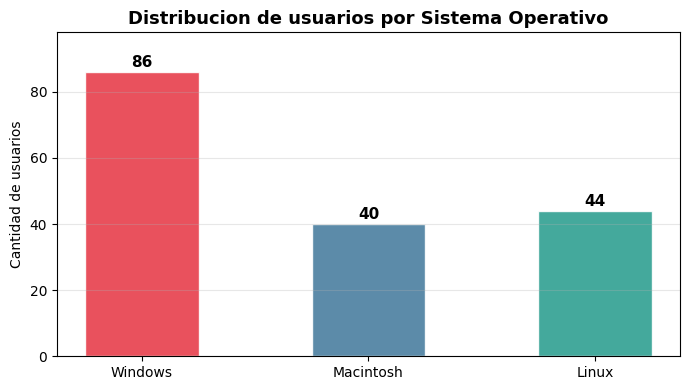

In [4]:
# Distribucion de clases con etiquetas
conteo = df['clase'].value_counts().sort_index()
conteo.index = [SO_MAP[i] for i in conteo.index]
print("Distribucion de clases:")
print(conteo)
print()
print(f"Total usuarios: {len(df)}")
print(f"Desbalance: Windows representa el {conteo['Windows']/len(df)*100:.1f}% del dataset")

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(conteo.index, conteo.values,
                color=[COLORS[k] for k in conteo.index],
                edgecolor='white', alpha=0.88, width=0.5)
for b, v in zip(barras, conteo.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, str(v),
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribucion de usuarios por Sistema Operativo', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de usuarios')
ax.set_ylim(0, conteo.max() + 12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('act2_viz0_clases.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Exploración de los datos (EDA)

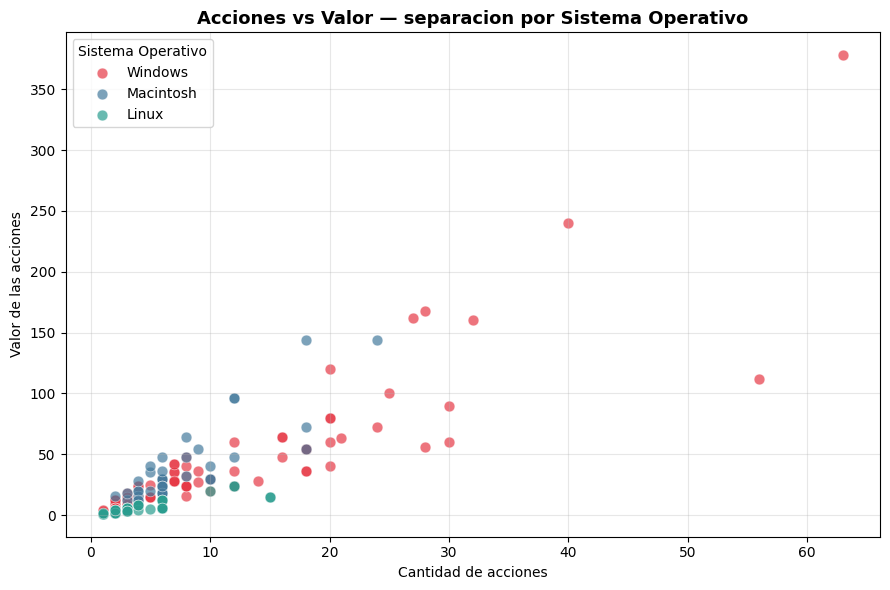

Interpretacion:
  Linux (verde): cluster concentrado en acciones bajas y valor bajo.
  Windows (rojo) y Mac (azul): mayor dispersion, valores de acciones y valor mas altos.
  Esta separacion visual anticipa que el modelo podra distinguir Linux facilmente.


In [5]:
# ── Viz 1: Scatter acciones vs valor coloreado por SO ───────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for label, name in SO_MAP.items():
    sub = df[df['clase'] == label]
    ax.scatter(sub['acciones'], sub['valor'],
               color=COLORS[name], label=name,
               alpha=0.7, s=60, edgecolors='white', linewidths=0.4)

ax.set_title('Acciones vs Valor — separacion por Sistema Operativo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de acciones')
ax.set_ylabel('Valor de las acciones')
ax.legend(title='Sistema Operativo', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('act2_viz1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretacion:")
print("  Linux (verde): cluster concentrado en acciones bajas y valor bajo.")
print("  Windows (rojo) y Mac (azul): mayor dispersion, valores de acciones y valor mas altos.")
print("  Esta separacion visual anticipa que el modelo podra distinguir Linux facilmente.")

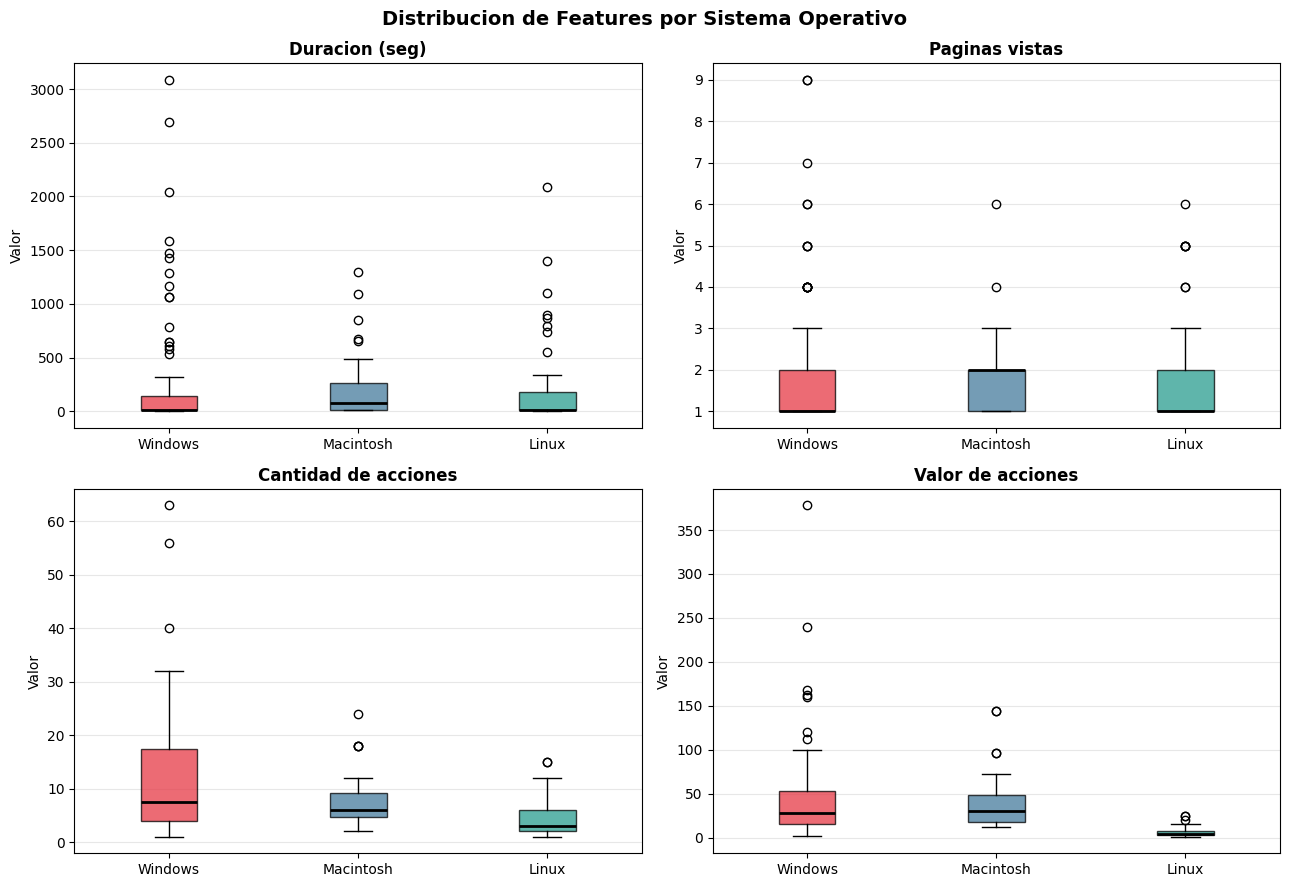

Interpretacion:
  Linux tiene 'acciones' y 'valor' claramente menores que Windows y Mac.
  'duracion' y 'paginas' presentan solapamiento entre los tres SO.


In [6]:
# ── Viz 2: Boxplots de las 4 features por SO ───────────────────────────────
features = ['duracion', 'paginas', 'acciones', 'valor']
titulos  = ['Duracion (seg)', 'Paginas vistas', 'Cantidad de acciones', 'Valor de acciones']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (feat, tit) in enumerate(zip(features, titulos)):
    grupos = [df.loc[df['clase'] == label, feat].values for label in [0, 1, 2]]
    bp = axes[i].boxplot(grupos, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [COLORS[n] for n in SO_NAMES]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    axes[i].set_xticklabels(SO_NAMES, fontsize=10)
    axes[i].set_title(tit, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valor')
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Distribucion de Features por Sistema Operativo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('act2_viz2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretacion:")
print("  Linux tiene 'acciones' y 'valor' claramente menores que Windows y Mac.")
print("  'duracion' y 'paginas' presentan solapamiento entre los tres SO.")

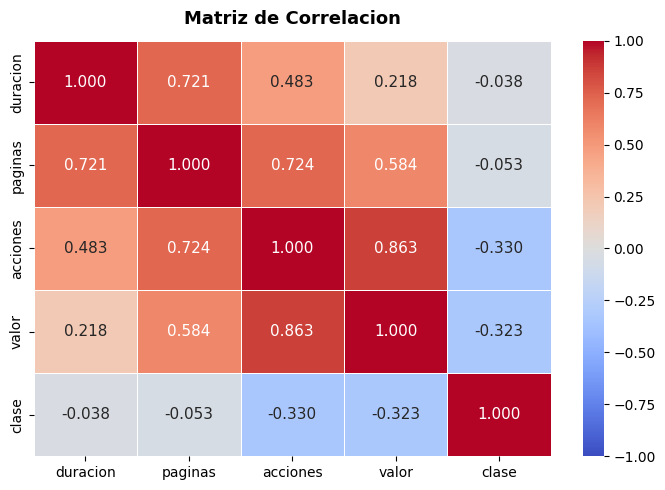

Correlacion con 'clase':
acciones   -0.330
valor      -0.323
paginas    -0.053
duracion   -0.038
Name: clase, dtype: float64


In [7]:
# ── Viz 3: Heatmap de correlaciones ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 11})
ax.set_title('Matriz de Correlacion', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('act2_viz3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlacion con 'clase':")
print(df.corr()['clase'].drop('clase').sort_values().round(3))

---
## 3. Preprocesamiento y división de datos

In [8]:
X = df.drop('clase', axis=1)
y = df['clase']

# stratify=y garantiza la misma proporcion de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler: necesario para KNN (sensible a escalas)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print()
print("Proporcion de clases en train:")
print((y_train.value_counts(normalize=True).sort_index()
       .rename(index=SO_MAP) * 100).round(1).astype(str) + '%')
print()
print("Proporcion de clases en test:")
print((y_test.value_counts(normalize=True).sort_index()
       .rename(index=SO_MAP) * 100).round(1).astype(str) + '%')

X_train: (136, 4)  |  X_test: (34, 4)

Proporcion de clases en train:
clase
Windows      50.7%
Macintosh    23.5%
Linux        25.7%
Name: proportion, dtype: object

Proporcion de clases en test:
clase
Windows      50.0%
Macintosh    23.5%
Linux        26.5%
Name: proportion, dtype: object


---
## 4. Modelado

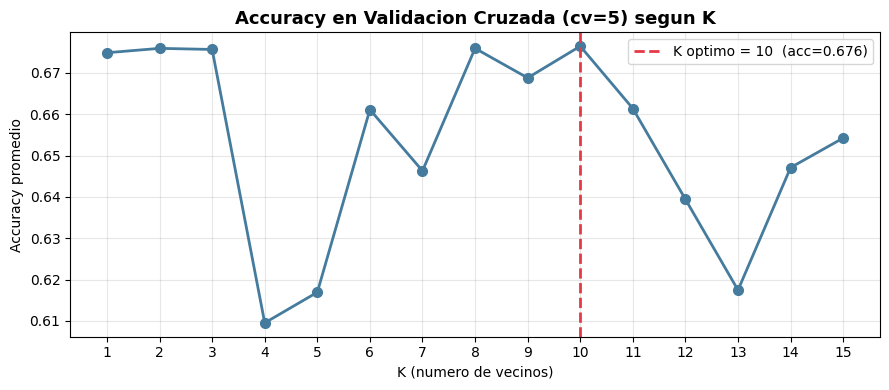

K optimo seleccionado: 10  |  Accuracy CV: 0.6765


In [9]:
# ── KNN: busqueda del K optimo con validacion cruzada ──────────────────────
k_range = range(1, 16)
acc_cv = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_tmp, X_train_sc, y_train, cv=5, scoring='accuracy')
    acc_cv.append(scores.mean())

k_optimo = k_range[np.argmax(acc_cv)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), acc_cv, marker='o', color='#457b9d', linewidth=2, markersize=7)
ax.axvline(k_optimo, color='#e63946', linestyle='--', lw=2,
           label=f'K optimo = {k_optimo}  (acc={max(acc_cv):.3f})')
ax.set_title('Accuracy en Validacion Cruzada (cv=5) segun K', fontsize=13, fontweight='bold')
ax.set_xlabel('K (numero de vecinos)')
ax.set_ylabel('Accuracy promedio')
ax.set_xticks(list(k_range))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('act2_viz4_koptimo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"K optimo seleccionado: {k_optimo}  |  Accuracy CV: {max(acc_cv):.4f}")

  MODELO 1 — KNN  (k=10)
  Accuracy en test: 0.5588  (55.9%)

              precision    recall  f1-score   support

     Windows       0.61      0.65      0.63        17
   Macintosh       0.50      0.38      0.43         8
       Linux       0.50      0.56      0.53         9

    accuracy                           0.56        34
   macro avg       0.54      0.53      0.53        34
weighted avg       0.56      0.56      0.55        34



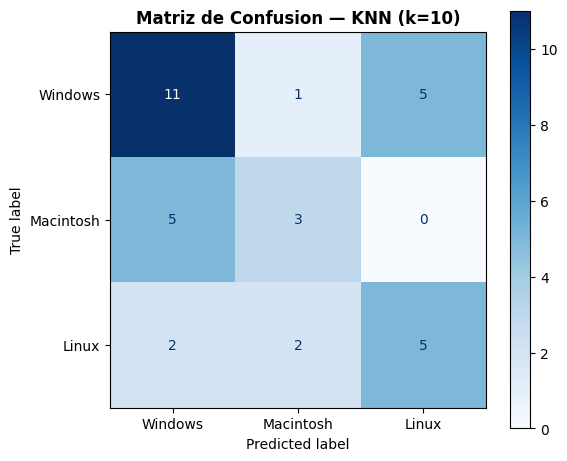

In [10]:
# ── KNN: entrenamiento y evaluacion ────────────────────────────────────────
print("=" * 55)
print(f"  MODELO 1 — KNN  (k={k_optimo})")
print("=" * 55)

knn = KNeighborsClassifier(n_neighbors=k_optimo)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"  Accuracy en test: {acc_knn:.4f}  ({acc_knn*100:.1f}%)")
print()
print(classification_report(y_test, y_pred_knn, target_names=SO_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=SO_NAMES,
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusion — KNN (k={k_optimo})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('act2_viz5_cm_knn.png', dpi=150, bbox_inches='tight')
plt.show()

  MODELO 2 — Arbol de Decision (max_depth=4)
  Accuracy en test: 0.6176  (61.8%)

              precision    recall  f1-score   support

     Windows       0.73      0.65      0.69        17
   Macintosh       0.67      0.25      0.36         8
       Linux       0.50      0.89      0.64         9

    accuracy                           0.62        34
   macro avg       0.63      0.60      0.56        34
weighted avg       0.66      0.62      0.60        34



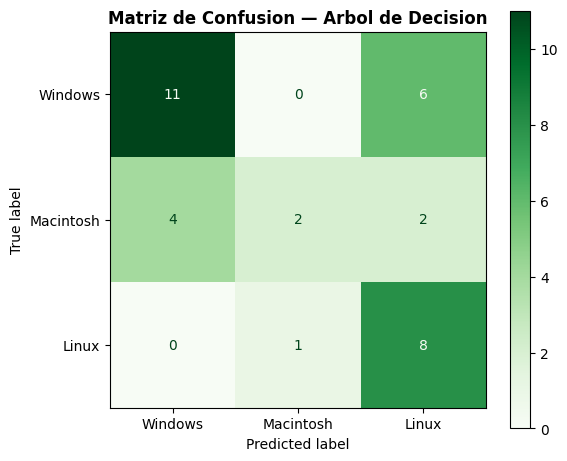

In [11]:
# ── Decision Tree: entrenamiento y evaluacion ──────────────────────────────
print("=" * 55)
print("  MODELO 2 — Arbol de Decision (max_depth=4)")
print("=" * 55)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"  Accuracy en test: {acc_dt:.4f}  ({acc_dt*100:.1f}%)")
print()
print(classification_report(y_test, y_pred_dt, target_names=SO_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=SO_NAMES,
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de Confusion — Arbol de Decision', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('act2_viz6_cm_dt.png', dpi=150, bbox_inches='tight')
plt.show()

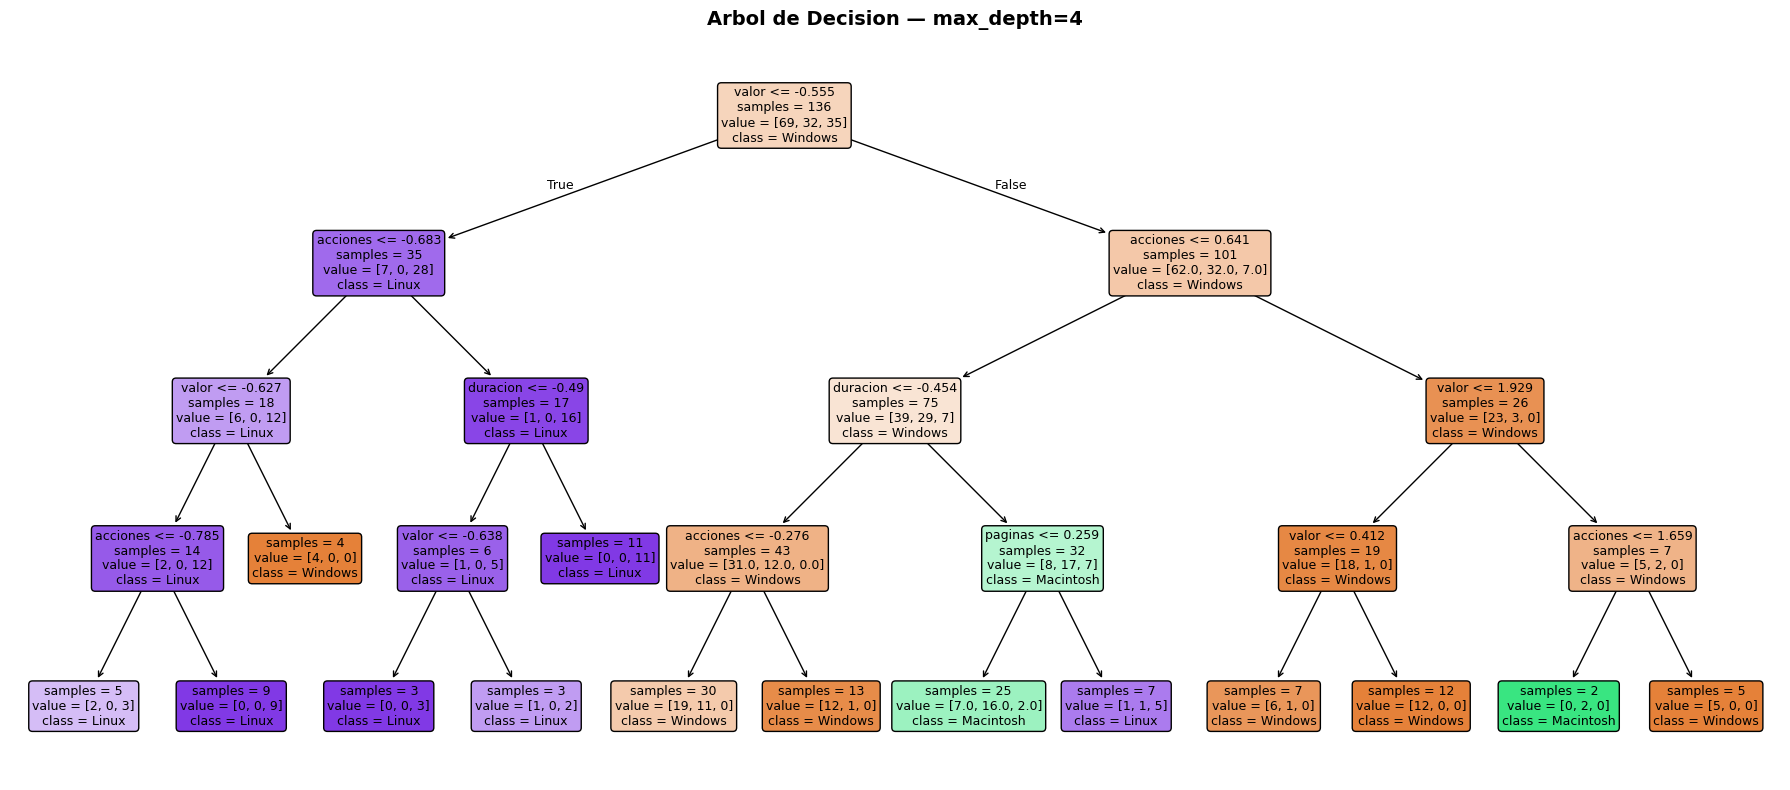

Importancia de features (Decision Tree):
valor       0.5602
acciones    0.2294
duracion    0.1334
paginas     0.0770


In [12]:
# ── Visualizacion del arbol ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt,
          feature_names=list(X.columns),
          class_names=SO_NAMES,
          filled=True, rounded=True,
          fontsize=9, ax=ax,
          impurity=False)
ax.set_title('Arbol de Decision — max_depth=4', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('act2_viz7_arbol.png', dpi=150, bbox_inches='tight')
plt.show()

# Importancia de features
feat_imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Importancia de features (Decision Tree):")
print(feat_imp.round(4).to_string())

In [13]:
# ── Tabla comparativa ──────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

comp = pd.DataFrame({
    'Modelo':    [f'KNN (k={k_optimo})', 'Arbol de Decision (depth=4)'],
    'Accuracy':  [round(acc_knn, 4), round(acc_dt, 4)],
    'F1 macro':  [round(f1_score(y_test, y_pred_knn, average='macro'), 4),
                  round(f1_score(y_test, y_pred_dt,  average='macro'), 4)],
    'Precision': [round(precision_score(y_test, y_pred_knn, average='macro'), 4),
                  round(precision_score(y_test, y_pred_dt,  average='macro'), 4)],
    'Recall':    [round(recall_score(y_test, y_pred_knn, average='macro'), 4),
                  round(recall_score(y_test, y_pred_dt,  average='macro'), 4)],
})
print("=" * 60)
print("  COMPARATIVA DE MODELOS")
print("=" * 60)
print(comp.to_string(index=False))
print()
mejor = comp.loc[comp['Accuracy'].idxmax(), 'Modelo']
print(f"Mejor modelo por Accuracy: {mejor}")

  COMPARATIVA DE MODELOS
                     Modelo  Accuracy  F1 macro  Precision  Recall
                 KNN (k=10)    0.5588    0.5278     0.5370  0.5259
Arbol de Decision (depth=4)    0.6176    0.5637     0.6333  0.5953

Mejor modelo por Accuracy: Arbol de Decision (depth=4)


---
## 5. Predicción con nuevos usuarios

### Ejemplo de uso del modelo entrenado

In [14]:
# Predecir el SO de nuevos usuarios
nuevos = pd.DataFrame({
    'duracion': [120,  500, 15],
    'paginas':  [3,    2,   1],
    'acciones': [8,    12,  2],
    'valor':    [40,   60,  3]
})

nuevos_sc = scaler.transform(nuevos)
preds_knn = knn.predict(nuevos_sc)
preds_dt  = dt.predict(nuevos_sc)
proba_knn = knn.predict_proba(nuevos_sc)

print("Prediccion de SO para nuevos usuarios:")
print("-" * 55)
for i, row in nuevos.iterrows():
    print(f"Usuario {i+1}: dur={row['duracion']}s  pag={row['paginas']}  "
          f"acc={row['acciones']}  val={row['valor']}")
    print(f"  KNN predice: {SO_MAP[preds_knn[i]]} "
          f"(confianza: {proba_knn[i].max()*100:.0f}%)")
    print(f"  DT  predice: {SO_MAP[preds_dt[i]]}")
    print()

Prediccion de SO para nuevos usuarios:
-------------------------------------------------------
Usuario 1: dur=120s  pag=3  acc=8  val=40
  KNN predice: Macintosh (confianza: 60%)
  DT  predice: Linux

Usuario 2: dur=500s  pag=2  acc=12  val=60
  KNN predice: Windows (confianza: 50%)
  DT  predice: Macintosh

Usuario 3: dur=15s  pag=1  acc=2  val=3
  KNN predice: Linux (confianza: 70%)
  DT  predice: Linux



---
## 6. Conclusiones

### Hallazgos principales

1. **`acciones` y `valor` son las features mas discriminativas** (correlacion -0.33 y -0.32 con la clase; Linux tiene valores muy bajos en ambas).
2. **Linux es el SO mas facil de clasificar**: forma un cluster compacto en el espacio (acciones, valor), lo que se refleja en alta recall para Linux en ambos modelos.
3. **Windows y Macintosh se confunden entre si** con mayor frecuencia porque sus patrones de navegacion se superponen.
4. **`duracion` y `paginas` aportan poca informacion discriminativa** — el arbol de decision apenas los usa como features de split.
5. El **separador de miles en `duracion`** fue el mayor desafio tecnico: sin `thousands='.'` en `pd.read_csv`, los valores se leian como flotantes incorrectos.

### Proximos pasos sugeridos
- Probar **Random Forest** para reducir la varianza del arbol individual.
- Aplicar **SMOTE** si el desbalance afecta el recall de Macintosh.
- Evaluar con **validacion cruzada estratificada** para estimaciones mas robustas.
- Recolectar mas datos de Macintosh (subrepresentado: 40/170 = 23.5%).
